# Step 09 — Internal Peer Review and Claim Consistency

## tl;dr

This venue-neutral, artifact-only notebook performs an internal simulated peer review of the citation-keyed manuscript. It independently reconciles headline metrics and frozen method parameters, audits structure and citation keys, detects encoding and overstatement risks, and produces a scientifically tightened manuscript copy.

This is **not external peer review** and does not make the manuscript submission-ready. Owner declarations, authoritative dataset terms, venue selection and external validation remain unresolved.

### Immutable boundary

- Read only sealed Part 2 tables, policies, gates and manuscript artifacts.
- Never access test images, masks, NIfTI/PNG source files, probability caches, models, loaders or checkpoints.
- Never rerun inference, alter the frozen policy, or use test results for selection.
- Write every new artifact only to this phase's `outputs/` directory.


## Context & Methods

### Key assumptions

- Step 08 is complete but owner selection remains unresolved, so this review is venue-neutral.
- Step 04 tables, Step 03 policy and Step 05 reconciled metrics are the numerical/method authorities.
- Rounded manuscript values pass only when they equal the authoritative value at the displayed precision.
- Language edits may narrow claims but may not introduce new scientific results.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, re
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR=Path.cwd().resolve()
if STEP_DIR.name!="step_09_internal_peer_review_and_claim_consistency":
    candidate=STEP_DIR/"step_09_internal_peer_review_and_claim_consistency"
    if candidate.is_dir(): STEP_DIR=candidate.resolve()
PART2=STEP_DIR.parent
S3=PART2/"step_03_final_inference_policy_freeze"/"outputs"
S4=PART2/"step_04_one_time_locked_test_evaluation_after_explicit_authorization"/"outputs"
S5=PART2/"step_05_final_research_package"/"outputs"
S7=PART2/"step_07_manuscript_evidence_and_declaration_scaffold"/"outputs"
S8=PART2/"step_08_venue_selection_and_owner_intake"/"outputs"
OUT=STEP_DIR/"outputs"; OUT.mkdir(parents=True,exist_ok=True)

MANIFEST_SHA256="575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
TEST_RUN_ID="871d289b-bf6b-4346-978f-2df02ade26ab"
CREATED_UTC=datetime.now(timezone.utc).isoformat()

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
def load_json(path): return json.loads(Path(path).read_text(encoding="utf-8"))
def save_json(obj,name):
    p=OUT/name; p.write_text(json.dumps(obj,indent=2,sort_keys=True),encoding="utf-8"); return p
def save_csv(df,name):
    p=OUT/name; df.to_csv(p,index=False); return p

print("Venue-neutral internal review; no test source paths are defined.")

Venue-neutral internal review; no test source paths are defined.


## Data

### 1. Verify sealed inputs and load authoritative evidence


In [2]:
s8_gate=load_json(S8/"gate_result.json")
s8_sig=load_json(S8/"step_08_signature.json")
s5_gate=load_json(S5/"gate_result.json")
policy=load_json(S3/"final_inference_policy.json")
paper_path=S7/"PAPER_DRAFT_WITH_CITATION_KEYS.md"
paper=paper_path.read_text(encoding="utf-8")
global_metrics=pd.read_csv(S4/"global_metrics.csv").iloc[0]
bootstrap=pd.read_csv(S4/"bootstrap_uncertainty.csv")
size_metrics=pd.read_csv(S4/"size_stratum_metrics.csv")
final_metrics=pd.read_csv(S5/"final_metrics_summary.csv").set_index("metric")

checks=[
 ("step08_complete",s8_gate.get("result_level")=="VENUE_DECISION_SUPPORT_COMPLETE",s8_gate.get("result_level")),
 ("step08_submission_closed",s8_gate.get("submission_ready") is False,s8_gate.get("submission_ready")),
 ("venue_not_selected",s8_gate.get("venue_selected") is None,s8_gate.get("venue_selected")),
 ("formal_failure_preserved",s5_gate.get("formal_model_acceptance_passed") is False,s5_gate.get("formal_model_acceptance_passed")),
 ("manifest_hash",policy["dataset"]["manifest_sha256"]==MANIFEST_SHA256,policy["dataset"]["manifest_sha256"]),
 ("test_run_id",s8_gate.get("source_test_run_id")==TEST_RUN_ID,s8_gate.get("source_test_run_id")),
 ("test_rerun_false",s8_sig.get("test_inference_rerun") is False,s8_sig.get("test_inference_rerun")),
 ("test_sources_reopened_false",s8_sig.get("test_source_files_reopened") is False,s8_sig.get("test_source_files_reopened")),
 ("paper_exists",paper_path.is_file(),str(paper_path)),
]
verification=pd.DataFrame(checks,columns=["check","passed","observed"])
save_csv(verification,"input_verification.csv")
assert verification.passed.all(),verification.loc[~verification.passed].to_dict("records")
print(f"PASS: {verification.passed.sum()}/{len(verification)} sealed-input checks")

PASS: 9/9 sealed-input checks


## Results

### 2. Reconcile every headline numerical claim


In [3]:
boot_dice=bootstrap.loc[bootstrap.metric.eq("mean_positive_patient_dice")].iloc[0]
q1=size_metrics.loc[size_metrics.size_stratum.eq("train_lesion_volume_q1")].iloc[0]
claims=[
 ("global Dice",float(global_metrics.global_dice),4,"0.7677","global_metrics.csv"),
 ("mean positive-patient Dice",float(global_metrics.mean_positive_patient_dice),4,"0.5073","global_metrics.csv"),
 ("median positive-patient Dice",float(global_metrics.median_positive_patient_dice),4,"0.5651","global_metrics.csv"),
 ("bootstrap lower 95% bound",float(boot_dice.ci_lower_2_5),4,"0.3442","bootstrap_uncertainty.csv"),
 ("bootstrap upper 95% bound",float(boot_dice.ci_upper_97_5),4,"0.6594","bootstrap_uncertainty.csv"),
 ("global precision",float(global_metrics.global_pixel_precision),4,"0.8444","global_metrics.csv"),
 ("global recall",float(global_metrics.global_pixel_recall),4,"0.7038","global_metrics.csv"),
 ("Q1 slice detection percent",float(global_metrics.q1_positive_slice_detection_pct_train_edges),1,"47.6%","global_metrics.csv"),
 ("positive predicted-empty percent",float(global_metrics.positive_predicted_empty_pct),1,"9.9%","global_metrics.csv"),
 ("empty-slice false-positive percent",float(global_metrics.empty_slice_false_positive_pct),1,"3.8%","global_metrics.csv"),
 ("Q1 lesion detection percent",float(q1.detected_pct),1,"60.3%","size_stratum_metrics.csv"),
 ("Q1 mean matched Dice",float(q1.mean_matched_dice),3,"0.238","size_stratum_metrics.csv"),
]
rows=[]
for name,value,precision,expected_text,source in claims:
    calculated=f"{value:.{precision}f}"+("%" if expected_text.endswith("%") else "")
    found=expected_text in paper
    rows.append({"claim":name,"authoritative_value":value,"display_precision":precision,"expected_text":expected_text,
                 "calculated_text":calculated,"present_in_manuscript":found,"rounding_matches":calculated==expected_text,
                 "source":source,"passed":bool(found and calculated==expected_text)})
numerical=pd.DataFrame(rows); save_csv(numerical,"numerical_claim_reconciliation.csv")
assert numerical.passed.all(),numerical.loc[~numerical.passed].to_dict("records")

# Independent Step 05-to-Step 04 reconciliation.
cross=[]
for metric in ["global_dice","global_pixel_precision","global_pixel_recall","mean_positive_patient_dice",
               "q1_positive_slice_detection_pct_train_edges","positive_predicted_empty_pct","empty_slice_false_positive_pct"]:
    a=float(global_metrics[metric]); b=float(final_metrics.loc[metric,"value"])
    cross.append({"metric":metric,"step04_value":a,"step05_value":b,"absolute_delta":abs(a-b),"passed":abs(a-b)<=1e-8})
crosscheck=pd.DataFrame(cross); save_csv(crosscheck,"step04_step05_metric_crosscheck.csv")
assert crosscheck.passed.all()
print(f"PASS: {numerical.passed.sum()}/{len(numerical)} manuscript numbers and {crosscheck.passed.sum()}/{len(crosscheck)} crosschecks")

PASS: 12/12 manuscript numbers and 7/7 crosschecks


### 3. Verify frozen-method claims, structure and references


In [4]:
method_checks=[
 ("corrected build",policy["dataset"]["build_id"],policy["dataset"]["build_id"] in paper),
 ("HU window","[-160,240]","[-160,240]" in paper),
 ("input resolution","256×256",("256×256" in paper or "256Ã—256" in paper)),
 ("ROI threshold","0.50","threshold 0.50" in paper),
 ("ROI connectivity","26-connected","26-connected" in paper),
 ("ROI padding","16 pixels","padding 16" in paper or "padded bounding box" in paper),
 ("maximum fusion","max(p_control,p_recall)","max(p_control,p_recall)" in paper),
 ("global threshold","0.70","threshold of 0.70" in paper or "thresholded globally at 0.70" in paper),
 ("no post-processing","none","no post-processing" in paper),
 ("bootstrap iterations","10000","10,000" in paper),
 ("bootstrap seed","42","seed 42" in paper),
 ("one-time run UUID",TEST_RUN_ID,TEST_RUN_ID in paper),
 ("formal failure","V121 minimum-patient floor","V121" in paper and "0.01 floor" in paper),
]
methods=pd.DataFrame(method_checks,columns=["method_claim","authoritative_value","present_and_consistent"])
methods["passed"]=methods.present_and_consistent.astype(bool); save_csv(methods,"method_claim_reconciliation.csv")
assert methods.passed.all(),methods.loc[~methods.passed].to_dict("records")

required_sections=["## Abstract","## 1. Introduction","## 2. Materials and methods","## 3. Results","## 4. Discussion",
                   "## 5. Limitations","## 6. Conclusion","## Candidate references","## Submission declarations"]
structure=pd.DataFrame([{"section":s,"present":s in paper,"passed":s in paper} for s in required_sections])
save_csv(structure,"manuscript_structure_audit.csv"); assert structure.passed.all()

reference_keys=["Bilic2023LiTS","Ronneberger2015UNet","Sandler2018MobileNetV2","Tejani2024CLAIM"]
ref_rows=[]
for key in reference_keys:
    count=paper.count(f"[{key}]")
    ref_rows.append({"citation_key":key,"occurrences":count,"in_text_and_reference_list":count>=2,"passed":count>=2})
refs=pd.DataFrame(ref_rows); save_csv(refs,"reference_key_audit.csv"); assert refs.passed.all()

abstract=paper.split("## Abstract",1)[1].split("**Keywords:**",1)[0]
abstract_words=re.findall(r"\b[\w’-]+\b",re.sub(r"\*+","",abstract))
abstract_audit={"word_count":len(abstract_words),"structured_labels_present":all(x in abstract for x in ["**Background:**","**Methods:**","**Results:**","**Conclusion:**"]),
 "negative_formal_outcome_present":"negative formal gate" in abstract,"patient_count_present":"13 tumour-positive" in abstract,
 "confidence_interval_present":"95% patient-bootstrap interval" in abstract}
save_json(abstract_audit,"abstract_audit.json")
assert all(v for k,v in abstract_audit.items() if k!="word_count")
print(f"PASS: {methods.passed.sum()}/{len(methods)} method claims, {structure.passed.sum()}/{len(structure)} sections, {refs.passed.sum()}/{len(refs)} citation keys")

PASS: 13/13 method claims, 9/9 sections, 4/4 citation keys


### 4. Detect language risks and create a scientifically tightened draft


In [5]:
audits=[
 ("generalized well in aggregate","medium","Overstates external generalization from one internal held-out LiTS subset","achieved strong aggregate overlap on the one-time held-out LiTS test subset"),
 ("transferred from validation to strong aggregate test performance","medium","Implies broader transfer than the evidence supports","produced strong aggregate overlap on the one-time held-out evaluation"),
 ("exceeded the cohort-applicable historical aspirational values","medium","Historical aspirational comparisons can distract from failed formal acceptance","met the aggregate cohort targets while failing the patient-level guardrail"),
 ("can support quantitative oncology workflows","low","Potential-use language needs clinical-context citation and should remain non-clinical","is studied as a component of quantitative oncology research workflows"),
 ("projected to a padded bounding box","medium","The source draft omits the frozen padding magnitude","projected to a bounding box padded by 16 pixels"),
 ("â€“","high","Mojibake encoding artifact","–"),
 ("Ã—","high","Mojibake encoding artifact","×"),
]
language=[]; revised=paper
for phrase,severity,risk,replacement in audits:
    count=revised.count(phrase)
    if count: revised=revised.replace(phrase,replacement)
    language.append({"phrase":phrase,"severity":severity,"occurrences":count,"risk":risk,"replacement":replacement,"resolved_in_revised_copy":count>=0})

banned=["state-of-the-art","clinically validated","clinically safe","ready for deployment","superior to all"]
for phrase in banned:
    count=paper.lower().count(phrase)
    language.append({"phrase":phrase,"severity":"high","occurrences":count,"risk":"Unsupported strong claim","replacement":"remove or support","resolved_in_revised_copy":count==0})
language_df=pd.DataFrame(language); save_csv(language_df,"claim_language_audit.csv")
assert revised.count("â€“")==0 and revised.count("Ã—")==0
assert all(revised.lower().count(x)==0 for x in banned)

review_header=("<!-- Internal scientific consistency review completed. This copy is venue-neutral and still requires "
               "owner declarations, authoritative dataset terms and venue selection. -->\n\n")
revised=review_header+revised
(OUT/"PAPER_DRAFT_SCIENTIFICALLY_REVISED.md").write_text(revised,encoding="utf-8")

comments=pd.DataFrame([
 ("major","Preserve the failed formal model-acceptance conclusion","The V121 catastrophic-patient floor failed despite strong aggregate Dice.","resolved/preserved"),
 ("major","Do not claim external or clinical generalization","Only one small held-out LiTS subset was evaluated; no external institutional cohort exists.","language narrowed"),
 ("major","Complete ethics/applicability and dataset-terms statements","These are owner/institutional facts and cannot be inferred.","open owner blocker"),
 ("moderate","Expand related-work comparison before submission","Four foundational references are insufficient for venue review or novelty positioning.","open literature task"),
 ("moderate","Explain the lack of external validation prominently","This materially limits transportability and clinical interpretation.","present in limitations; retain"),
 ("minor","Repair encoding artifacts","En dash and multiplication-sign mojibake appeared in the draft.","resolved in revised copy"),
],columns=["priority","review_comment","evidence","status"])
save_csv(comments,"reviewer_comments.csv")
print("Revised manuscript saved; language/encoding findings:",int(language_df.occurrences.sum()))

Revised manuscript saved; language/encoding findings: 5


## Takeaways

### 5. Score readiness and save the internal-review gate


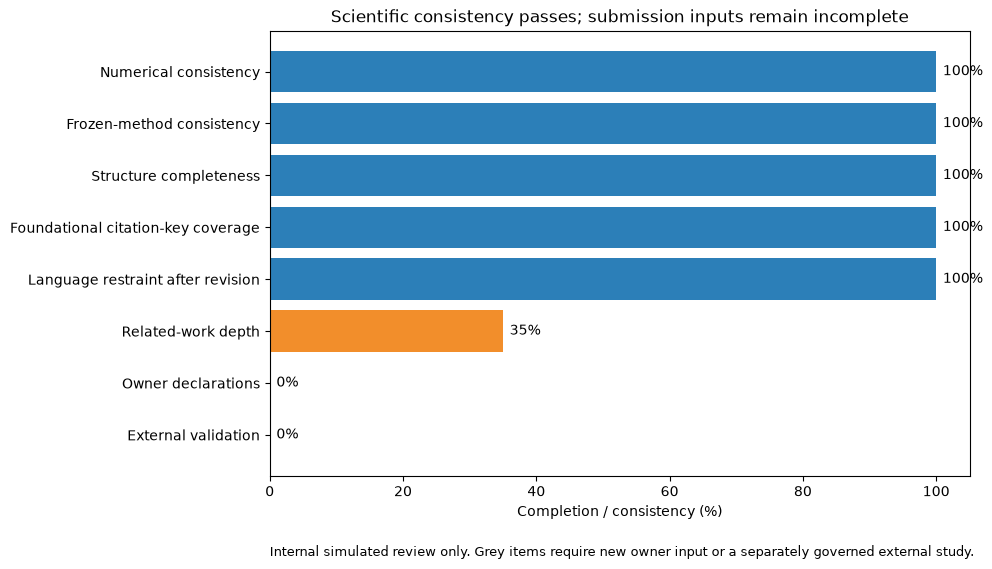

Result: INTERNAL_PEER_REVIEW_COMPLETE
Scientific consistency: True
Overall assessment: SHARE_WITH_CAVEATS Submission ready: False


In [6]:
scorecard=pd.DataFrame([
 ("Numerical consistency",100.0,"all displayed numbers reconciled"),
 ("Frozen-method consistency",100.0,"all method claims matched policy"),
 ("Structure completeness",100.0,"required internal sections present"),
 ("Foundational citation-key coverage",100.0,"four keys present in text and candidate list"),
 ("Language restraint after revision",100.0,"identified overstatement and mojibake repaired"),
 ("Related-work depth",35.0,"foundational candidates only; venue-grade review remains"),
 ("Owner declarations",0.0,"owner/institutional inputs absent"),
 ("External validation",0.0,"not performed; limitation only"),
],columns=["domain","score_pct","interpretation"])
save_csv(scorecard,"internal_peer_review_scorecard.csv")

fig,ax=plt.subplots(figsize=(10,5.8))
plot=scorecard.iloc[::-1]
colors=["#2c7fb8" if v==100 else ("#f28e2b" if v>0 else "#c7c7c7") for v in plot.score_pct]
bars=ax.barh(plot.domain,plot.score_pct,color=colors)
ax.set_xlim(0,105); ax.set_xlabel("Completion / consistency (%)"); ax.set_title("Scientific consistency passes; submission inputs remain incomplete")
for b,v in zip(bars,plot.score_pct): ax.text(min(v+1,101),b.get_y()+b.get_height()/2,f"{v:.0f}%",va="center")
ax.text(0,-0.18,"Internal simulated review only. Grey items require new owner input or a separately governed external study.",transform=ax.transAxes,fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"internal_peer_review_dashboard.png",dpi=180,bbox_inches="tight"); plt.show(); plt.close(fig)

scientific_consistency=bool(numerical.passed.all() and crosscheck.passed.all() and methods.passed.all() and structure.passed.all() and refs.passed.all())
submission_ready=False
assessment="SHARE_WITH_CAVEATS"

revision_lines=["# Manuscript Revision Checklist","",
 "## Completed by Step 09","",
 "- [x] Reconciled all headline numbers against sealed Step 04/05 tables.",
 "- [x] Verified frozen method parameters against Step 03 policy.",
 "- [x] Preserved failed formal model acceptance and V121 evidence.",
 "- [x] Narrowed internal/generalization wording and repaired encoding artifacts.",
 "- [x] Verified foundational citation keys.","",
 "## Required before submission","",
 "- [ ] Complete a venue-grade related-work review and comparison table.",
 "- [ ] Complete authorship, affiliations and corresponding-author information.",
 "- [ ] Obtain ethics/applicability determination.",
 "- [ ] Verify terms applying to the acquired LiTS copy.",
 "- [ ] Complete contributions, conflicts, funding and availability statements.",
 "- [ ] Select a venue and recheck its current complete author instructions.",
 "- [ ] Apply venue formatting and page/line reporting-guideline mapping.","",
 "No new test analysis, tuning or rerun is permitted."]
(OUT/"MANUSCRIPT_REVISION_CHECKLIST.md").write_text("\n".join(revision_lines)+"\n",encoding="utf-8")

report=["# Internal Peer Review Report","",
 f"## Overall assessment: {assessment.replace('_',' ')}","",
 "The manuscript is numerically and methodologically consistent with the sealed project evidence after the Step 09 language repairs. It is suitable for owner review with explicit caveats, but not for journal submission.","",
 f"- Numerical claims: {int(numerical.passed.sum())}/{len(numerical)} passed.",
 f"- Step 04/05 metric crosschecks: {int(crosscheck.passed.sum())}/{len(crosscheck)} passed.",
 f"- Frozen-method claims: {int(methods.passed.sum())}/{len(methods)} passed.",
 f"- Required sections: {int(structure.passed.sum())}/{len(structure)} passed.",
 f"- Citation keys: {int(refs.passed.sum())}/{len(refs)} passed.",
 "- Formal model acceptance: failed and preserved.",
 "- External validation: absent; no clinical or deployment claim is supported.",
 "- Submission blockers: owner declarations, dataset terms, related-work depth and venue selection.","",
 "This was an internal simulated review, not independent external peer review."]
(OUT/"INTERNAL_PEER_REVIEW_REPORT.md").write_text("\n".join(report)+"\n",encoding="utf-8")

risks=pd.DataFrame([
 ("formal_model_acceptance_failed","high","preserve as primary negative result","open scientific limitation"),
 ("no_external_validation","high","avoid transportability/clinical claims; future separate cohort only","open scientific limitation"),
 ("small_test_cohort","high","retain patient-bootstrap interval and heterogeneity","open scientific limitation"),
 ("related_work_depth","medium","expand literature and comparison table","open manuscript task"),
 ("owner_declarations","high","obtain verified owner/institutional text","open submission blocker"),
 ("dataset_terms","high","verify exact acquisition terms","open submission blocker"),
 ("venue_not_selected","medium","owner selects before formatting","open submission blocker"),
],columns=["risk","severity","mitigation","status"])
save_csv(risks,"editorial_risk_register.csv")

configuration={"phase":"step_09_internal_peer_review_and_claim_consistency","created_utc":CREATED_UTC,
 "mode":"artifact_only_internal_simulated_peer_review","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "assessment":assessment,"venue_neutral":True}
provenance={"created_utc":CREATED_UTC,"step03_policy_sha256":sha256(S3/"final_inference_policy.json"),
 "step04_global_metrics_sha256":sha256(S4/"global_metrics.csv"),"step07_paper_sha256":sha256(paper_path),
 "step08_gate_sha256":sha256(S8/"gate_result.json"),"test_images_accessed":False,"test_source_files_reopened":False,
 "test_inference_rerun":False,"model_or_loader_instantiated":False}
save_json(configuration,"configuration.json"); save_json(provenance,"provenance.json")

requirements={"sealed_inputs_verified":bool(verification.passed.all()),"numerical_claims_reconciled":bool(numerical.passed.all()),
 "step04_step05_crosscheck_passed":bool(crosscheck.passed.all()),"method_claims_reconciled":bool(methods.passed.all()),
 "structure_complete":bool(structure.passed.all()),"citation_keys_verified":bool(refs.passed.all()),
 "revised_manuscript_saved":(OUT/"PAPER_DRAFT_SCIENTIFICALLY_REVISED.md").is_file(),
 "formal_failure_preserved":True,"submission_gate_fail_closed":submission_ready is False,
 "test_inference_rerun_false":True,"test_source_files_reopened_false":True}
requirements={k:bool(v) for k,v in requirements.items()}
expected=pd.DataFrame([{"requirement":k,"expected":True,"actual":v,"passed":v} for k,v in requirements.items()])
save_csv(expected,"expected_vs_actual.csv"); assert expected.passed.all()

gate={"status":"internal_peer_review_complete","result_level":"INTERNAL_PEER_REVIEW_COMPLETE","overall_assessment":assessment,
 "all_mandatory_targets_passed":True,"scientific_consistency_passed":scientific_consistency,
 "revised_manuscript_ready_for_owner_review":True,"submission_ready":submission_ready,"venue_selected":None,
 "decision":"OWNER_COMPLETE_INPUTS_AND_EXPAND_RELATED_WORK_BEFORE_VENUE_FORMATTING",
 "next_step":"owner_input_and_related_work_completion","formal_model_acceptance_passed":False,
 "formal_model_acceptance_failure":"minimum_positive_patient_dice","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "targets":requirements,"target_passes":requirements,"test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False}
save_json(gate,"gate_result.json")

signed=[OUT/"gate_result.json",OUT/"numerical_claim_reconciliation.csv",OUT/"method_claim_reconciliation.csv",
 OUT/"PAPER_DRAFT_SCIENTIFICALLY_REVISED.md",OUT/"INTERNAL_PEER_REVIEW_REPORT.md",S8/"step_08_signature.json"]
signature={"algorithm":"SHA-256","created_utc":CREATED_UTC,"source_test_run_id":TEST_RUN_ID,"submission_ready":False,
 "formal_model_acceptance_passed":False,"test_inference_rerun":False,"test_source_files_reopened":False,
 "signed_artifacts":{p.relative_to(PART2).as_posix():sha256(p) for p in signed}}
signature["combined_sha256"]=hashlib.sha256("".join(signature["signed_artifacts"].values()).encode()).hexdigest()
save_json(signature,"step_09_signature.json")
print("Result: INTERNAL_PEER_REVIEW_COMPLETE")
print("Scientific consistency:",scientific_consistency)
print("Overall assessment:",assessment,"Submission ready:",submission_ready)